<a href="https://colab.research.google.com/github/Oluwasegun78/2025_CLAN_workshop/blob/main/python-basics/google-colab-r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corpus (Socio)phonetics

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


# Load libraries

In [4]:
library(ggplot2)
library(dplyr)

In [5]:
if (!requireNamespace("tidyverse", quietly = TRUE)) {
  install.packages("tidyverse")
}
if (!requireNamespace("readxl", quietly = TRUE)) {
  install.packages("readxl")
}
if (!requireNamespace("lme4", quietly = TRUE)) {
  install.packages("lme4")
}
if (!requireNamespace("lmerTest", quietly = TRUE)) {
  install.packages("lmerTest")
}
if (!requireNamespace("car", quietly = TRUE)) {
  install.packages("car")
}
if (!requireNamespace("broom.mixed", quietly = TRUE)) {
  install.packages("broom.mixed")
}
if (!requireNamespace("sjPlot", quietly = TRUE)) {
  install.packages("sjPlot")
}
if (!requireNamespace("performance", quietly = TRUE)) {
  install.packages("performance")
}
if (!requireNamespace("nnet", quietly = TRUE)) {
  install.packages("nnet")
}
if (!requireNamespace("knitr", quietly = TRUE)) {
  install.packages("knitr")
}

library(tidyverse)   # data wrangling
library(readxl)       # read .xlsx
library(lme4)         # GLMM
library(lmerTest)     # p-values via Satterthwaite (lm side); used mainly for consistency
library(car)          # Type III Wald chi-square tests for GLMM fixed effects
library(broom.mixed)  # tidy() for mixed models, exponentiated ORs
library(sjPlot)        # APA-style regression tables (tab_model)
library(performance)  # model diagnostics / R2 for GLMMs
library(nnet)          # multinomial logistic regression (RQ3)
library(knitr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘numDeriv’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘coda’, ‘furrr’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘param

In [11]:
df_raw <- read_excel("Palatalisation_alone_Akinola.xlsx", sheet = "Sheet1")

glimpse(df_raw)

Rows: 4,480
Columns: 12
$ Spk_code     <chr> "spkr_001", "spkr_002", "spkr_003", "spkr_004", "spkr_005…
$ Item         <chr> "appreciate", "appreciate", "appreciate", "appreciate", "…
$ Gender       <chr> "M", "F", "F", "F", "F", "F", "M", "F", "M", "M", "F", "F…
$ Age          <chr> "Young", "Young", "Young", "Young", "Young", "Young", "Yo…
$ Ethnic_group <chr> "Igbo", "Igbo", "Isoko", "Igbo", "Ethiope", "Igbo", "Igbo…
$ Region       <chr> "East", "East", "East", "East", "South_South", "East", "E…
$ Education    <chr> "Secondary", "Tertiary", "Secondary", "Secondary", "Secon…
$ Occupation   <chr> "Student", "Student", "Student", "Student", "Student", "E…
$ Orth_context <chr> "<c>/<i>", "<c>/<i>", "<c>/<i>", "<c>/<i>", "<c>/<i>", "<…
$ Phon_context <chr> "[s] - [S]", "[s] - [S]", "[s] - [S]", "[s] - [S]", "[s] …
$ Process_type <chr> "coronal-palatalisation", "coronal-palatalisation", "coro…
$ Realisation  <chr> "palatalised", "palatalised", "palatalised", "palatalised…


To resolve the error, please upload the `Palatalisation_alone_Akinola.xlsx` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar (folder icon), then clicking 'Upload to session storage' (file with an arrow icon) and selecting your file. Once uploaded, the file will be accessible directly by its name in the Colab session.

In [12]:
# After uploading, you can verify the file is present in the current directory
list.files()

[1] "Palatalisation_alone_Akinola.xlsx" "sample_data"

In [13]:
df <- df_raw %>%
  mutate(
    Gender = str_trim(Gender),

    # --- Process_type: collapse typo/spacing variants ---
    Process_type_clean = case_when(
      str_detect(Process_type, regex("coron[ae][- ]palatalisation", ignore_case = TRUE)) ~ "coronal-palatalisation",
      str_detect(Process_type, regex("spirantisation", ignore_case = TRUE)) ~ "spirantisation",
      TRUE ~ Process_type
    ),

    # --- Phon_context: strip inconsistent spacing around the hyphen ---
    Phon_context_clean = str_replace_all(Phon_context, "\\s*-\\s*", "-"),

    # parse "[s]-[S]" into an input (underlying) and output (surface) segment
    Input_segment  = str_remove_all(str_extract(Phon_context_clean, "^\\[[^\\]]+\\]"), "\\[|\\]"),
    Output_segment = str_remove_all(str_extract(Phon_context_clean, "\\[[^\\]]+\\]$"), "\\[|\\]"),

    # --- Realisation: collapse case/spacing/underscore variants ---
    Realisation_clean = case_when(
      str_detect(Realisation, regex("^pec_non", ignore_case = TRUE))            ~ "pec_non-palatalised",
      str_detect(Realisation, regex("^pec_palatal", ignore_case = TRUE))        ~ "pec_palatalisation",
      str_detect(Realisation, regex("^non", ignore_case = TRUE))                ~ "non-palatalised",
      str_detect(Realisation, regex("^palatal[_-]?affricate", ignore_case = TRUE)) ~ "palatal-affricate",
      str_detect(Realisation, regex("^palatalised_voiced", ignore_case = TRUE)) ~ "palatalised-voiced",
      str_detect(Realisation, regex("^palatalis", ignore_case = TRUE))          ~ "palatalised",
      TRUE ~ Realisation
    ),

    # binary DV for RQ1/RQ2 (see note above re: pec_ categories)
    Realisation_binary = case_when(
      Realisation_clean %in% c("palatalised", "palatalised-voiced", "palatal-affricate", "pec_palatalisation") ~ "palatalised",
      Realisation_clean %in% c("non-palatalised", "pec_non-palatalised") ~ "non-palatalised",
      TRUE ~ NA_character_
    ),
    Realisation_binary = factor(Realisation_binary, levels = c("non-palatalised", "palatalised")),

    Age    = factor(Age, levels = c("Young", "Middle_aged", "Old")),
    Region = factor(Region),
    Education = factor(Education),
    Ethnic_group = factor(Ethnic_group),
    Input_segment = factor(Input_segment),
    Spk_code = factor(Spk_code),
    Item     = factor(Item)
  )

# sanity check: how many rows fell into each cleaned Realisation level?
df %>% count(Realisation, Realisation_clean) %>% arrange(Realisation_clean) %>% kable()

# any rows lost to NA in the binary DV (should only be if Realisation_clean unmatched)
sum(is.na(df$Realisation_binary))



|Realisation         |Realisation_clean   |    n|
|:-------------------|:-------------------|----:|
|Non-palatalised     |non-palatalised     |   11|
|non-palatalised     |non-palatalised     | 1176|
|Palatal-affricate   |palatal-affricate   |    4|
|palatal_affricate   |palatal-affricate   |    3|
|palatalisation      |palatalised         |   17|
|palatalised         |palatalised         | 2774|
|palatalised_voiced  |palatalised-voiced  |    2|
|pec_non-palatalised |pec_non-palatalised |    2|
|pec_palatalisation  |pec_palatalisation  |  491|

[1] 0

# RQ1 — Distribution of palatalised vs. non-palatalised variants

**H0₁:** no significant difference in the distribution of palatalised vs.
non-palatalised variants in educated NigE.
**H0₂ (alt.):** there is a significant difference.

In [14]:
rq1_tab <- df %>%
  filter(!is.na(Realisation_binary)) %>%
  count(Realisation_binary) %>%
  mutate(proportion = n / sum(n))

kable(rq1_tab, digits = 3, caption = "Distribution of palatalised vs. non-palatalised tokens")



Table: Distribution of palatalised vs. non-palatalised tokens

|Realisation_binary |    n| proportion|
|:------------------|----:|----------:|
|non-palatalised    | 1189|      0.265|
|palatalised        | 3291|      0.735|

In [15]:
# Chi-square goodness-of-fit test against a null of equal (50/50) distribution
rq1_chisq <- chisq.test(rq1_tab$n, p = c(0.5, 0.5))
rq1_chisq

# APA-style write-up helper
apa_chisq <- function(x) {
  sprintf("χ²(%d) = %.2f, p %s", x$parameter, x$statistic,
          ifelse(x$p.value < .001, "< .001", paste0("= ", round(x$p.value, 3))))
}
apa_chisq(rq1_chisq)


	Chi-squared test for given probabilities

data:  rq1_tab$n
X-squared = 986.25, df = 1, p-value < 2.2e-16


[1] "χ²(1) = 986.25, p < .001"

# Full picture for RQ3

In [16]:
df %>%
  count(Realisation_clean) %>%
  mutate(proportion = round(n / sum(n), 3)) %>%
  arrange(desc(n)) %>%
  kable(caption = "Full distribution of realisation types (pre-binary-collapse)")



Table: Full distribution of realisation types (pre-binary-collapse)

|Realisation_clean   |    n| proportion|
|:-------------------|----:|----------:|
|palatalised         | 2791|      0.623|
|non-palatalised     | 1187|      0.265|
|pec_palatalisation  |  491|      0.110|
|palatal-affricate   |    7|      0.002|
|palatalised-voiced  |    2|      0.000|
|pec_non-palatalised |    2|      0.000|

# RQ2 — Social and linguistic conditioning of palatalisation

**H0₃:** Age, region, age×region interaction, and phonetic context do **not**
significantly condition palatalisation.
**H0₄ (alt.):** they do.

Mixed-effects logistic regression (GLMM) with crossed random intercepts for
speaker (`Spk_code`) and lexical item (`Item`), since tokens are nested
within both speakers and words.

In [17]:
d_rq2 <- df %>% filter(!is.na(Realisation_binary))

# check level sizes for Input_segment before including as a factor
d_rq2 %>% count(Input_segment) %>% kable()



|Input_segment |    n|
|:-------------|----:|
|s             | 3200|
|t             | 1121|
|z             |  159|

In [18]:
# Null (random-effects only) model
m0 <- glmer(Realisation_binary ~ 1 + (1 | Spk_code) + (1 | Item),
            data = d_rq2, family = binomial(link = "logit"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))

# Full model: social factors (Age, Region, Age:Region) + linguistic factor (Input_segment)
m1 <- glmer(Realisation_binary ~ Age * Region + Input_segment +
              (1 | Spk_code) + (1 | Item),
            data = d_rq2, family = binomial(link = "logit"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))

summary(m1)


Correlation matrix not shown by default, as p = 14 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Realisation_binary ~ Age * Region + Input_segment + (1 | Spk_code) +  
    (1 | Item)
   Data: d_rq2
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

      AIC       BIC    logLik -2*log(L)  df.resid 
   2405.4    2507.9   -1186.7    2373.4      4464 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-17.9357  -0.1959   0.0624   0.1927   4.8459 

Random effects:
 Groups   Name        Variance Std.Dev.
 Spk_code (Intercept)  0.5249  0.7245  
 Item     (Intercept) 11.1955  3.3460  
Number of obs: 4480, groups:  Spk_code, 160; Item, 28

Fixed effects:
                                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       2.83782    0.79245   3.581 0.000342 ***
AgeMiddle_aged                   -0.25964    0.36136  -0.718 0.472450    
AgeOld                           -0.47991    0.

In [19]:
# Overall test of whether the fixed effects improve fit over the null model
anova(m0, m1, test = "Chisq")

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m0,3,2404.742,2423.964,-1199.371,2398.742,NA,NA,NA
m1,16,2405.359,2507.877,-1186.680,2373.359,25.38272,13,0.02054973


In [20]:
# Type III Wald chi-square tests for each fixed effect (tests H0_3 piece by piece)
Anova(m1, type = 3)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),12.824219,1,0.0003421613
Age,1.055077,2,0.5900555399
Region,5.182802,3,0.1588905195
Input_segment,9.526705,2,0.0085369397
Age:Region,5.762253,6,0.4503427759


In [21]:
# APA-style odds-ratio table with 95% CIs
tab_model(m1, transform = "exp", show.ci = 0.95, show.p = TRUE,
          title = "GLMM: log-odds of palatalisation (educated NigE)")

# tidy tibble version, exponentiated to odds ratios
broom.mixed::tidy(m1, effects = "fixed", conf.int = TRUE, exponentiate = TRUE) %>%
  kable(digits = 3, caption = "Fixed effects (odds ratios)")



Table: Fixed effects (odds ratios)

|effect |term                             | estimate| std.error| statistic| p.value| conf.low| conf.high|
|:------|:--------------------------------|--------:|---------:|---------:|-------:|--------:|---------:|
|fixed  |(Intercept)                      |   17.078|    13.534|     3.581|   0.000|    3.613|    80.720|
|fixed  |AgeMiddle_aged                   |    0.771|     0.279|    -0.718|   0.472|    0.380|     1.566|
|fixed  |AgeOld                           |    0.619|     0.317|    -0.935|   0.350|    0.226|     1.691|
|fixed  |RegionNorth                      |    0.549|     0.185|    -1.777|   0.076|    0.284|     1.064|
|fixed  |RegionSouth_South                |    0.616|     0.219|    -1.365|   0.172|    0.307|     1.235|
|fixed  |RegionWest                       |    0.987|     0.342|    -0.037|   0.971|    0.501|     1.946|
|fixed  |Input_segmentt                   |   17.634|    25.437|     1.989|   0.047|    1.044|   297.992|
|fixed  

In [22]:
# quick diagnostics: convergence, R2, ICC (speaker/item variance)
performance::check_convergence(m1)
performance::r2(m1)
performance::icc(m1)

[1] TRUE
attr(,"gradient")
[1] 7.46502e-05

# R2 for Mixed Models

  Conditional R2: 0.820
     Marginal R2: 0.178

ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.7808258,0.641649,0.641649


In [23]:
# Optional: simplified model without the Age:Region interaction, if m1 struggles
m1_noint <- glmer(Realisation_binary ~ Age + Region + Input_segment +
                     (1 | Spk_code) + (1 | Item),
                   data = d_rq2, family = binomial,
                   control = glmerControl(optimizer = "bobyqa"))
anova(m1_noint, m1, test = "Chisq")   # is the interaction justified?

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m1_noint,10,2399.049,2463.123,-1189.525,2379.049,NA,NA,NA
m1,16,2405.359,2507.877,-1186.680,2373.359,5.690147,6,0.458779


In [25]:
if (!requireNamespace("brms", quietly = TRUE)) {
  install.packages("brms")
}
library(brms)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘StanHeaders’, ‘inline’, ‘gridExtra’, ‘RcppParallel’, ‘QuickJSR’, ‘BH’, ‘checkmate’, ‘tensorA’, ‘distributional’, ‘ggridges’, ‘reshape2’, ‘mvtnorm’, ‘Brobdingnag’, ‘rstan’, ‘loo’, ‘posterior’, ‘rstantools’, ‘bayesplot’, ‘bridgesampling’, ‘future.apply’, ‘matrixStats’, ‘nleqslv’


Loading required package: Rcpp

Loading 'brms' package (version 2.23.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:lme4’:

    ngrps


The following object is masked from ‘package:stats’:

    ar


Compiling Stan program...

Start sampling



 Family: bernoulli 
  Links: mu = logit 
Formula: Realisation_binary ~ Age * Region + Input_segment + (1 | Spk_code) + (1 | Item) 
   Data: d_rq2 (Number of observations: 4480) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~Item (Number of levels: 28) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     3.71      0.66     2.67     5.23 1.00     1363     2800

~Spk_code (Number of levels: 160) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.81      0.09     0.64     0.99 1.00     3448     4647

Regression Coefficients:
                                 Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                            2.71      0.84     1.06     4.41 1.00
AgeMiddle_aged                      -0.26      0.39    -1.02     0.51 1.00
AgeOld                              -0.49      0.56    -1.61     0.59 1.0

In [26]:
m1_brm <- brm(Realisation_binary ~ Age * Region + Input_segment +
                (1 | Spk_code) + (1 | Item),
              data = d_rq2, family = bernoulli(link = "logit"),
              chains = 4, cores = 4, iter = 4000, seed = 1234)
summary(m1_brm)

Compiling Stan program...

Start sampling



 Family: bernoulli 
  Links: mu = logit 
Formula: Realisation_binary ~ Age * Region + Input_segment + (1 | Spk_code) + (1 | Item) 
   Data: d_rq2 (Number of observations: 4480) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~Item (Number of levels: 28) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     3.71      0.66     2.67     5.23 1.00     1363     2800

~Spk_code (Number of levels: 160) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.81      0.09     0.64     0.99 1.00     3448     4647

Regression Coefficients:
                                 Estimate Est.Error l-95% CI u-95% CI Rhat
Intercept                            2.71      0.84     1.06     4.41 1.00
AgeMiddle_aged                      -0.26      0.39    -1.02     0.51 1.00
AgeOld                              -0.49      0.56    -1.61     0.59 1.0

# RQ3 — Distinctive palatalised variants of educated NigE

**H0₅:** educated NigE does not exhibit distinctive palatalised variants.
**H0₆ (alt.):** it does.

This treats the *finer-grained* realisation categories (not collapsed to
binary) as the outcome of interest — i.e., are there realisation types
(e.g. `palatal-affricate`, `palatalised-voiced`, `pec_palatalisation`) whose
occurrence is patterned by/associated with specific social groups, which
would support their status as distinctive of (rather than incidental noise
in) educated NigE speech?

In [27]:
# Baseline: how common are the "non-canonical" variants overall?
distinctive_variants <- c("palatal-affricate", "palatalised-voiced", "pec_palatalisation", "pec_non-palatalised")

df %>%
  mutate(variant_status = if_else(Realisation_clean %in% distinctive_variants,
                                   "distinctive_variant", "canonical")) %>%
  count(variant_status) %>%
  mutate(proportion = round(n / sum(n), 3)) %>%
  kable(caption = "Proportion of tokens realised as a non-canonical/distinctive variant")



Table: Proportion of tokens realised as a non-canonical/distinctive variant

|variant_status      |    n| proportion|
|:-------------------|----:|----------:|
|canonical           | 3978|      0.888|
|distinctive_variant |  502|      0.112|

In [28]:
# Are distinctive variants distributed unevenly across Region? (chi-square test of independence)
tab_region <- table(df$Realisation_clean, df$Region)
tab_region

chisq_region <- chisq.test(tab_region)
chisq_region

                     
                      East North South_South West
  non-palatalised      256   347         273  311
  palatal-affricate      0     2           1    4
  palatalised          645   718         641  787
  palatalised-voiced     1     0           0    1
  pec_non-palatalised    2     0           0    0
  pec_palatalisation   104   137         121  129

Warning message in chisq.test(tab_region):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tab_region
X-squared = 20.327, df = 15, p-value = 0.1598


In [29]:
# Same test against Ethnic_group (collapse rare ethnic groups first to avoid
# low expected cell counts)
top_ethnic <- df %>% count(Ethnic_group, sort = TRUE) %>% slice_head(n = 6) %>% pull(Ethnic_group)

df_eth <- df %>% mutate(Ethnic_group_top = if_else(Ethnic_group %in% top_ethnic,
                                                     as.character(Ethnic_group), "Other"))

tab_eth <- table(df_eth$Realisation_clean, df_eth$Ethnic_group_top)
tab_eth

chisq_eth <- chisq.test(tab_eth, simulate.p.value = TRUE, B = 2000)
chisq_eth

                     
                      Esan Fulani Hausa Igbo Other Tànglè Yoruba
  non-palatalised       56     78   119  242   331     50    311
  palatal-affricate      0      1     0    0     2      0      4
  palatalised          120    169   201  608   803    103    787
  palatalised-voiced     0      0     0    1     0      0      1
  pec_non-palatalised    0      0     0    2     0      0      0
  pec_palatalisation    20     32    44   99   152     15    129


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  tab_eth
X-squared = 29.705, df = NA, p-value = 0.4548


In [30]:
# Multinomial logistic regression: which social/linguistic factors predict
# realisation TYPE (not just binary palatalised/non-palatalised)?
d_rq3 <- df %>% filter(!is.na(Realisation_clean))
d_rq3$Realisation_clean <- relevel(factor(d_rq3$Realisation_clean), ref = "non-palatalised")

m_multi <- multinom(Realisation_clean ~ Age + Region + Input_segment,
                     data = d_rq3, trace = FALSE)

summary(m_multi)

# Wald z-tests -> p-values for the multinomial coefficients
z <- summary(m_multi)$coefficients / summary(m_multi)$standard.errors
p <- (1 - pnorm(abs(z), 0, 1)) * 2
round(p, 3)

Warning message in sqrt(diag(vc)):
“NaNs produced”


Call:
multinom(formula = Realisation_clean ~ Age + Region + Input_segment, 
    data = d_rq3, trace = FALSE)

Coefficients:
                    (Intercept) AgeMiddle_aged       AgeOld RegionNorth
palatal-affricate   -71.0088843   -1.042178651 -40.37528400  65.7611688
palatalised           0.8971598   -0.048639828   0.08953231  -0.2078568
palatalised-voiced  -17.3733886   12.214735748  13.58411975 -29.3193669
pec_non-palatalised -15.0064997   10.625702475  11.82873806 -19.5824817
pec_palatalisation   -0.9055404    0.006255965   0.04180909  -0.0441862
                    RegionSouth_South   RegionWest Input_segmentt
palatal-affricate         65.38911418  66.67645449      1.9520996
palatalised               -0.07893090   0.01094735      0.7880608
palatalised-voiced       -21.16504609  -0.16186976    -16.8159777
pec_non-palatalised      -27.15510659 -27.61721812    -10.5763248
pec_palatalisation         0.07810944   0.02270784      0.6343668
                    Input_segmentz
palatal-affri

Warning message in sqrt(diag(vc)):
“NaNs produced”
Warning message in sqrt(diag(vc)):
“NaNs produced”


,(Intercept),AgeMiddle_aged,AgeOld,RegionNorth,RegionSouth_South,RegionWest,Input_segmentt,Input_segmentz
palatal-affricate,0,0.215,NaN,0.000,0.000,0.000,0.011,0
palatalised,0,0.530,0.474,0.046,0.469,0.917,0.000,0
palatalised-voiced,0,0.000,0.000,0.000,0.000,0.909,0.000,0
pec_non-palatalised,0,0.000,0.000,0.000,0.000,0.000,0.000,0
pec_palatalisation,0,0.957,0.824,0.779,0.631,0.887,0.000,0


In [46]:
m_multi_null <- multinom(Realisation_clean ~ 1,
                     data = d_rq3, trace = FALSE)

# Compare AIC values
print(paste("AIC for full multinomial model (m_multi):", AIC(m_multi)))
print(paste("AIC for null multinomial model (m_multi_null):", AIC(m_multi_null)))

[1] "AIC for full multinomial model (m_multi): 7732.16322987025"
[1] "AIC for null multinomial model (m_multi_null): 8127.97547656584"


In [31]:
# consistent APA-ish plotting theme for every figure below
theme_apa <- theme_minimal(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 13)
  )
theme_set(theme_apa)

# RQ1 — Distribution of palatalised vs. non-palatalised variants


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




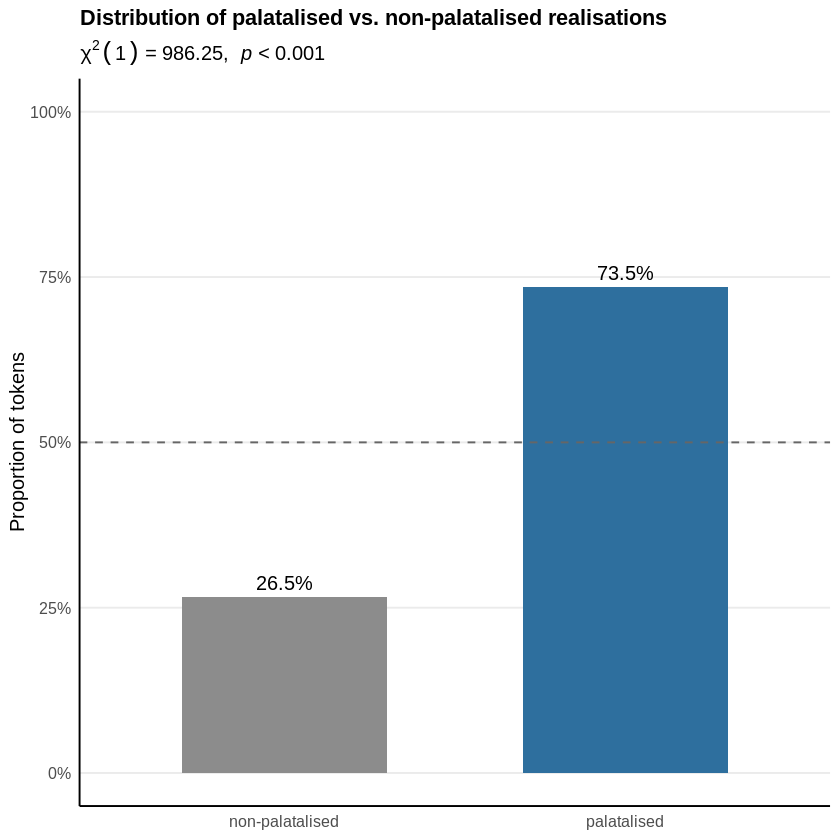

In [33]:
library(scales) # Load the scales package for percent_format()

ggplot(rq1_tab, aes(x = Realisation_binary, y = proportion, fill = Realisation_binary)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = percent(proportion, accuracy = 0.1)), vjust = -0.5, size = 4.2) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey40") +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  scale_fill_manual(values = c("non-palatalised" = "#8C8C8C", "palatalised" = "#2E6F9E")) +
  labs(
    title = "Distribution of palatalised vs. non-palatalised realisations",
    subtitle = expression(chi^2*(1) == 986.25*","~italic(p) < .001),
    x = NULL, y = "Proportion of tokens"
  )

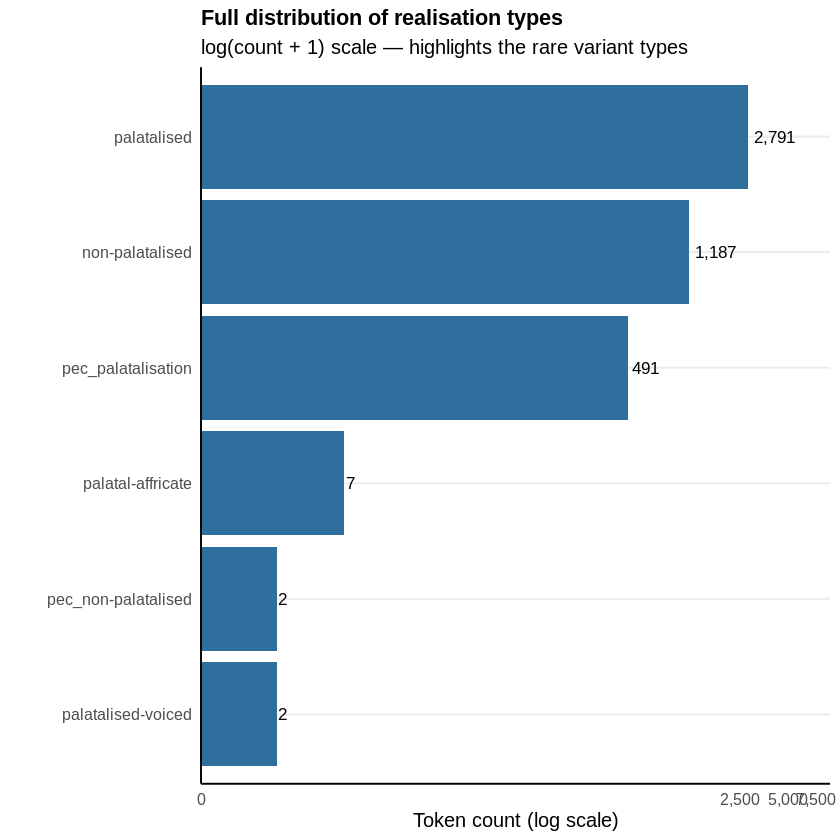

In [34]:
# full variant picture (log scale, since pec_palatalisation and the binary
# categories dwarf the rare variant types)
df %>%
  count(Realisation_clean) %>%
  mutate(Realisation_clean = fct_reorder(Realisation_clean, n)) %>%
  ggplot(aes(x = Realisation_clean, y = n)) +
  geom_col(fill = "#2E6F9E") +
  geom_text(aes(label = comma(n)), hjust = -0.15, size = 3.6) +
  coord_flip(clip = "off") +
  scale_y_continuous(trans = "log1p", labels = comma,
                      expand = expansion(mult = c(0, 0.15))) +
  labs(
    title = "Full distribution of realisation types",
    subtitle = "log(count + 1) scale — highlights the rare variant types",
    x = NULL, y = "Token count (log scale)"
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the sjPlot package.
  Please report the issue at <https://github.com/strengejacke/sjPlot/issues>.”


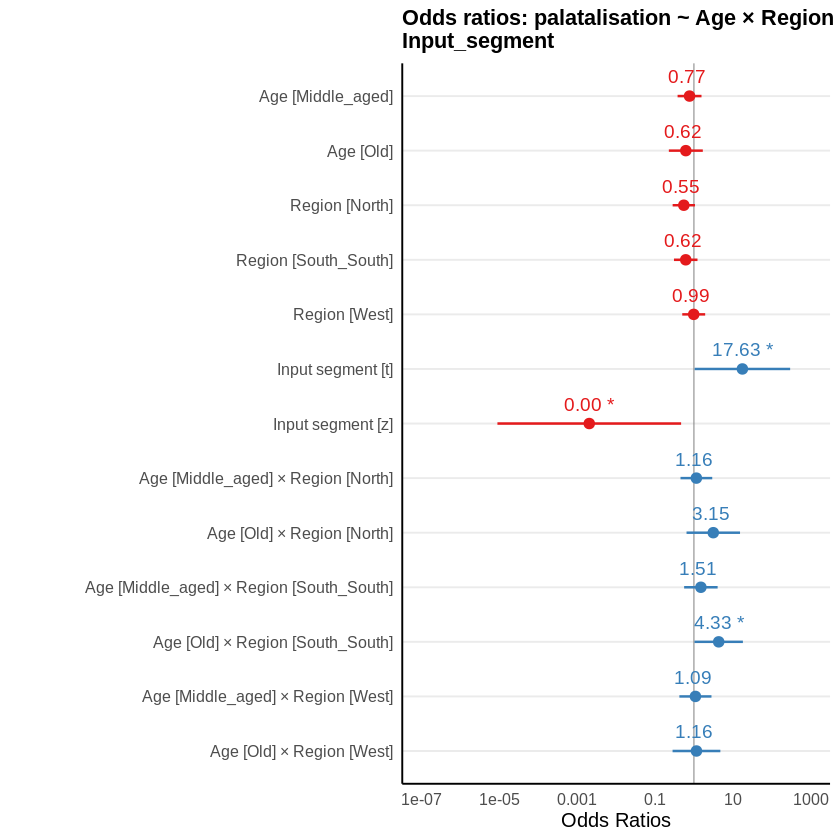

In [35]:
# sjPlot's built-in forest/dot-whisker plot of the GLMM fixed effects
plot_model(
  m1, transform = "exp", show.values = TRUE, value.offset = 0.35,
  vline.color = "grey50", title = "Odds ratios: palatalisation ~ Age × Region + Input_segment"
) + theme_apa

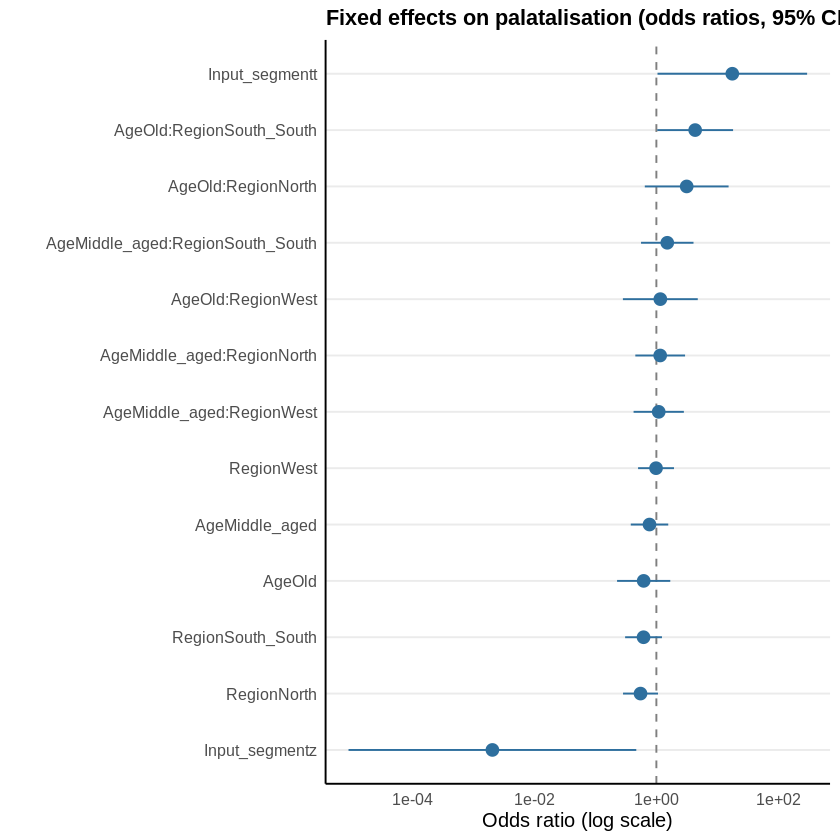

In [36]:
# manual ggplot version if you want full control over labels/ordering
or_tab <- broom.mixed::tidy(m1, effects = "fixed", conf.int = TRUE, exponentiate = TRUE) %>%
  filter(term != "(Intercept)") %>%
  mutate(term = fct_reorder(term, estimate))

ggplot(or_tab, aes(x = estimate, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = conf.low, xmax = conf.high), color = "#2E6F9E", size = 0.6) +
  scale_x_log10() +
  labs(
    title = "Fixed effects on palatalisation (odds ratios, 95% CI)",
    x = "Odds ratio (log scale)", y = NULL
  )

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.

Ignoring unknown labels:
• linetype : "Region"
• shape : "Region"


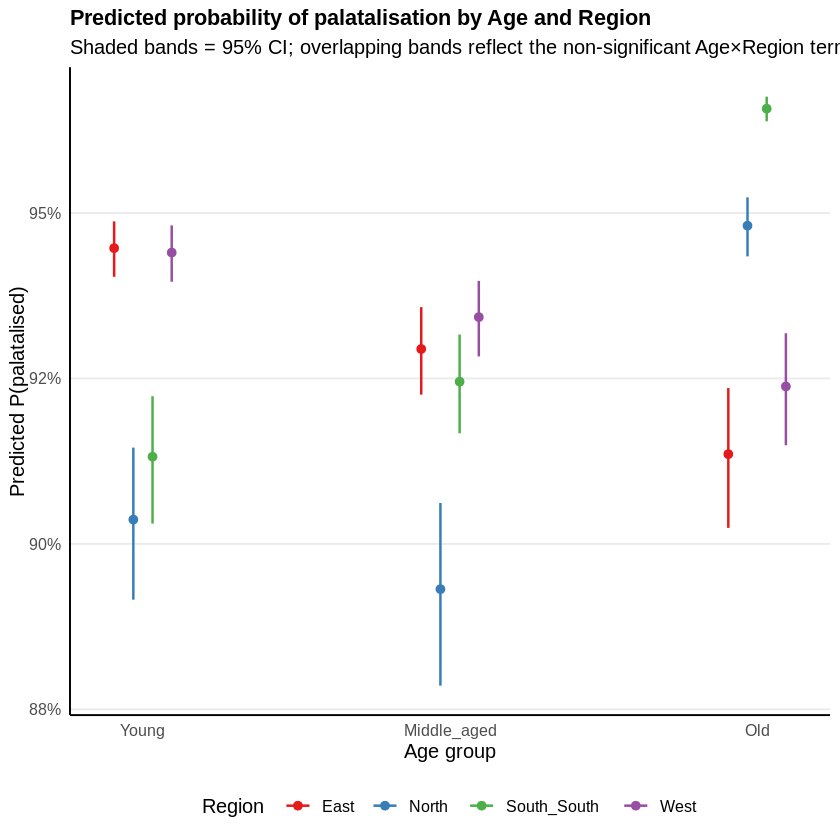

In [37]:
# marginal predicted probabilities, averaging over Input_segment,
# with random effects set to population average (re.form = NA)
preds_age_region <- ggeffects::ggpredict(m1, terms = c("Age", "Region"))

plot(preds_age_region) +
  labs(
    title = "Predicted probability of palatalisation by Age and Region",
    subtitle = "Shaded bands = 95% CI; overlapping bands reflect the non-significant Age×Region term",
    x = "Age group", y = "Predicted P(palatalised)"
  ) +
  theme_apa

## Palatalisation rate by phonetic input segment

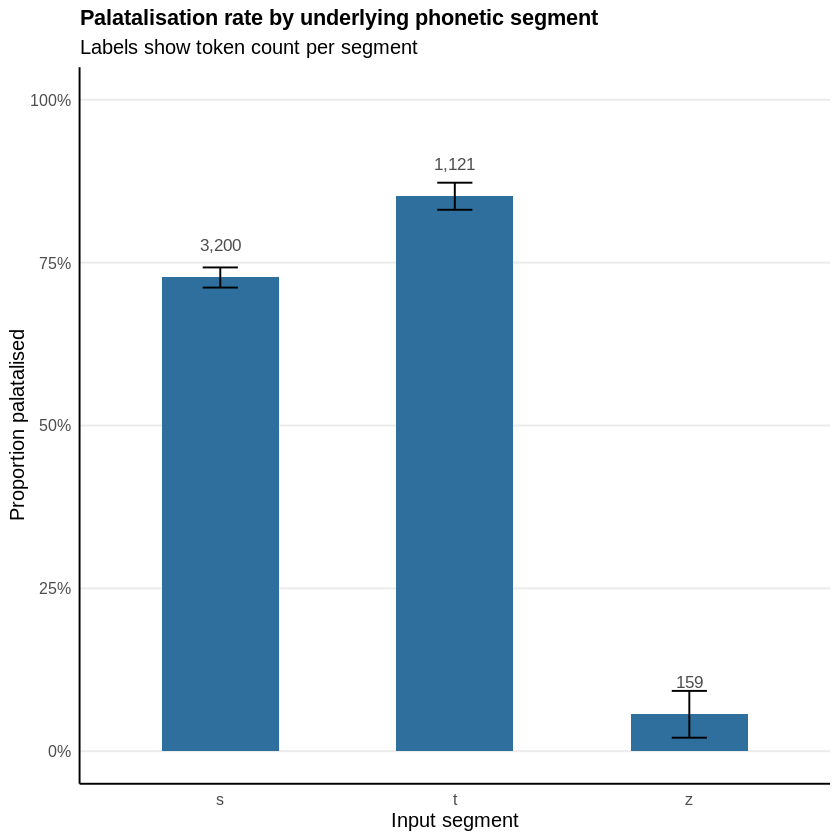

In [38]:
seg_tab <- d_rq2 %>%
  group_by(Input_segment) %>%
  summarise(
    n = n(),
    prop_palatalised = mean(Realisation_binary == "palatalised"),
    se = sqrt(prop_palatalised * (1 - prop_palatalised) / n)
  )

ggplot(seg_tab, aes(x = Input_segment, y = prop_palatalised)) +
  geom_col(fill = "#2E6F9E", width = 0.5) +
  geom_errorbar(aes(ymin = prop_palatalised - 1.96 * se, ymax = prop_palatalised + 1.96 * se),
                width = 0.15) +
  geom_text(aes(label = comma(n)), vjust = -2.2, size = 3.6, color = "grey30") +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(
    title = "Palatalisation rate by underlying phonetic segment",
    subtitle = "Labels show token count per segment",
    x = "Input segment", y = "Proportion palatalised"
  )

## Random effects (item-level "caterpillar" plot)

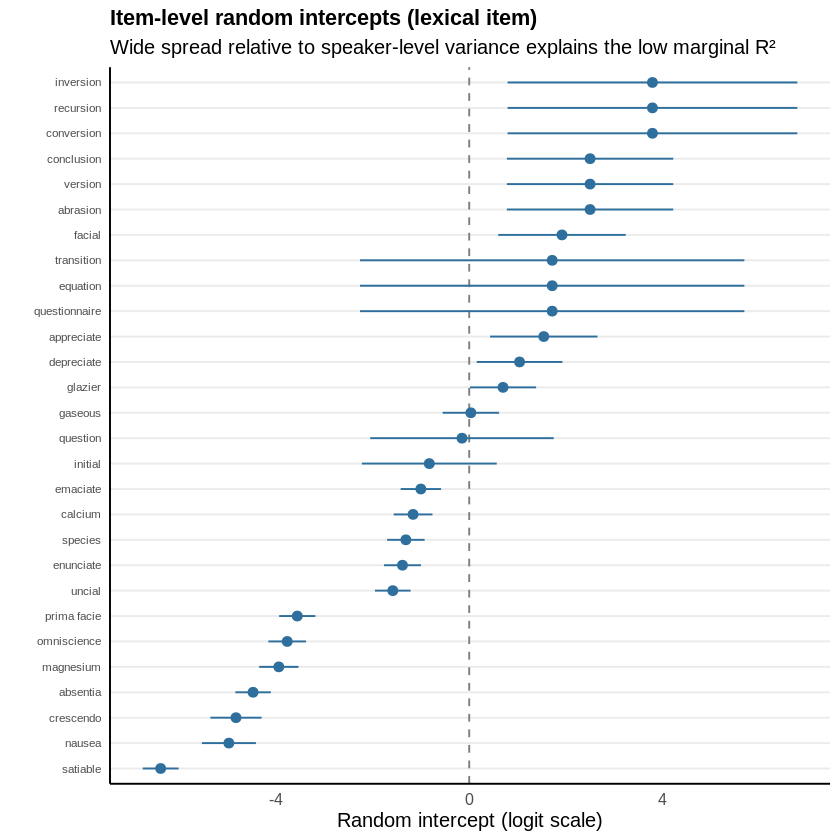

In [39]:
# item random intercepts tend to dominate variance here (see ICC), so this
# plot is the most diagnostic random-effects figure for this model
ranef_item <- lme4::ranef(m1, condVar = TRUE)$Item
item_df <- tibble(
  Item = rownames(ranef_item),
  estimate = ranef_item[, "(Intercept)"],
  se = sqrt(attr(ranef_item, "postVar")[1, 1, ])
) %>%
  mutate(Item = fct_reorder(Item, estimate))

ggplot(item_df, aes(x = estimate, y = Item)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = estimate - 1.96 * se, xmax = estimate + 1.96 * se),
                   color = "#2E6F9E", size = 0.4) +
  labs(
    title = "Item-level random intercepts (lexical item)",
    subtitle = "Wide spread relative to speaker-level variance explains the low marginal R²",
    x = "Random intercept (logit scale)", y = NULL
  ) +
  theme(axis.text.y = element_text(size = 7))

In [ ]:
# RQ3 — Distinctive palatalised variants of educated NigE

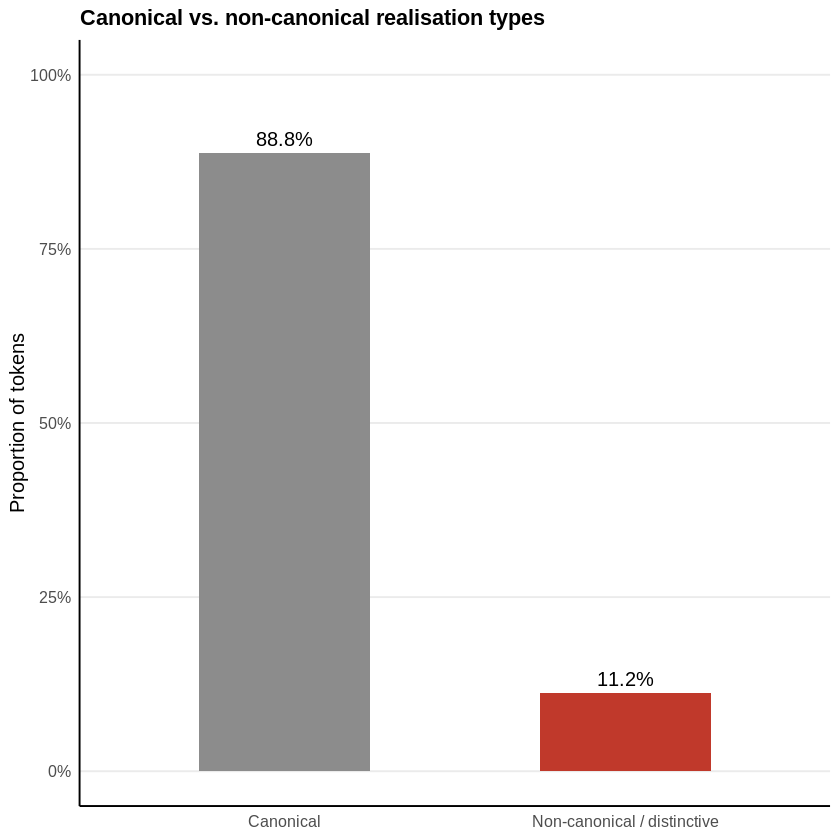

In [40]:
distinctive_variants <- c("palatal-affricate", "palatalised-voiced", "pec_palatalisation", "pec_non-palatalised")

df %>%
  mutate(variant_status = if_else(Realisation_clean %in% distinctive_variants,
                                   "Non-canonical / distinctive", "Canonical")) %>%
  count(variant_status) %>%
  mutate(proportion = n / sum(n)) %>%
  ggplot(aes(x = variant_status, y = proportion, fill = variant_status)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = percent(proportion, accuracy = 0.1)), vjust = -0.5) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  scale_fill_manual(values = c("Canonical" = "#8C8C8C", "Non-canonical / distinctive" = "#C0392B")) +
  labs(title = "Canonical vs. non-canonical realisation types", x = NULL, y = "Proportion of tokens")

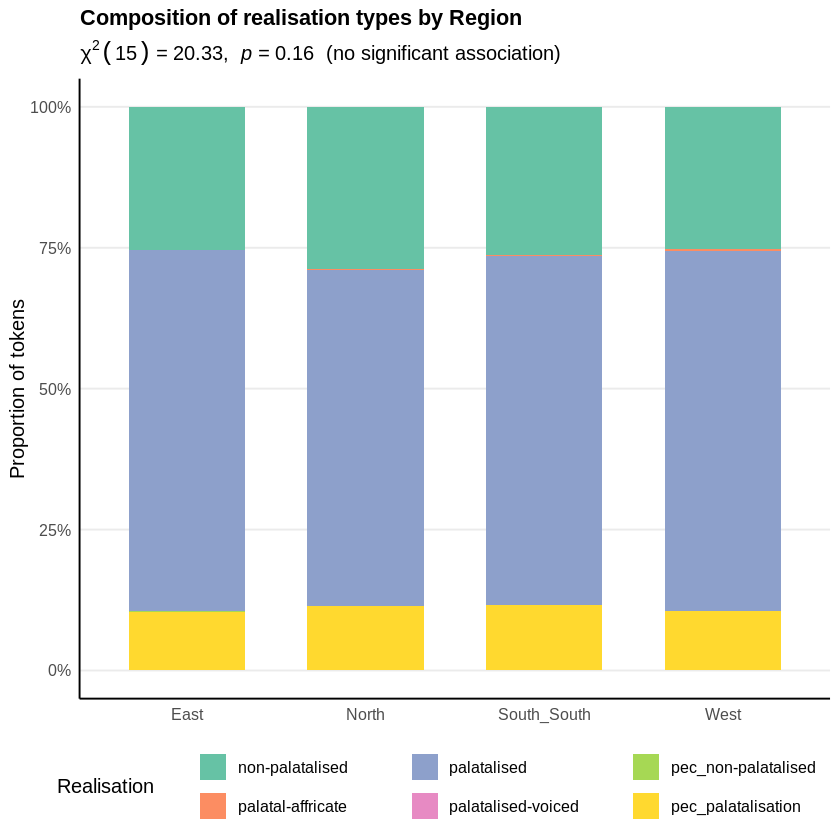

In [41]:
# proportional stacked bar: composition of realisation types within each Region
df %>%
  count(Region, Realisation_clean) %>%
  group_by(Region) %>%
  mutate(prop = n / sum(n)) %>%
  ggplot(aes(x = Region, y = prop, fill = Realisation_clean)) +
  geom_col(position = "stack", width = 0.65) +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_brewer(palette = "Set2", name = "Realisation") +
  labs(
    title = "Composition of realisation types by Region",
    subtitle = expression(chi^2*(15) == 20.33*","~italic(p) == .160~"(no significant association)"),
    x = NULL, y = "Proportion of tokens"
  )

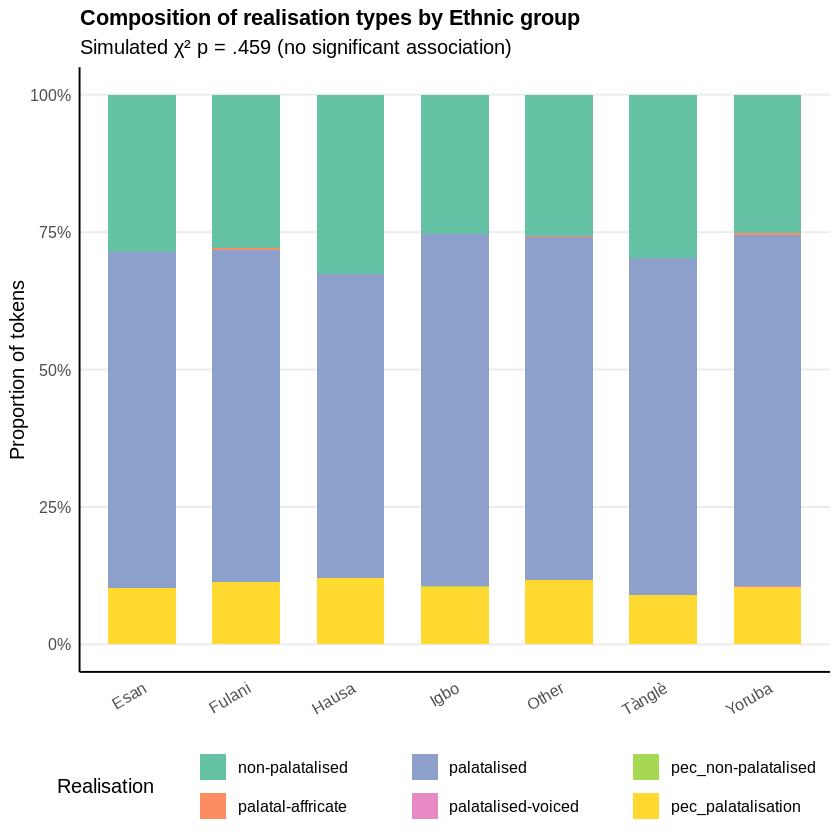

In [45]:
top_ethnic <- df %>% count(Ethnic_group, sort = TRUE) %>% slice_head(n = 6) %>% pull(Ethnic_group)

df %>%
  mutate(Ethnic_group_top = if_else(Ethnic_group %in% top_ethnic, as.character(Ethnic_group), "Other")) %>%
  count(Ethnic_group_top, Realisation_clean) %>%
  group_by(Ethnic_group_top) %>%
  mutate(prop = n / sum(n)) %>%
  ggplot(aes(x = Ethnic_group_top, y = prop, fill = Realisation_clean)) +
  geom_col(position = "stack", width = 0.65) +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_brewer(palette = "Set2", name = "Realisation") +
  labs(
    title = "Composition of realisation types by Ethnic group",
    subtitle = "Simulated χ² p = .459 (no significant association)",
    x = NULL, y = "Proportion of tokens"
  ) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

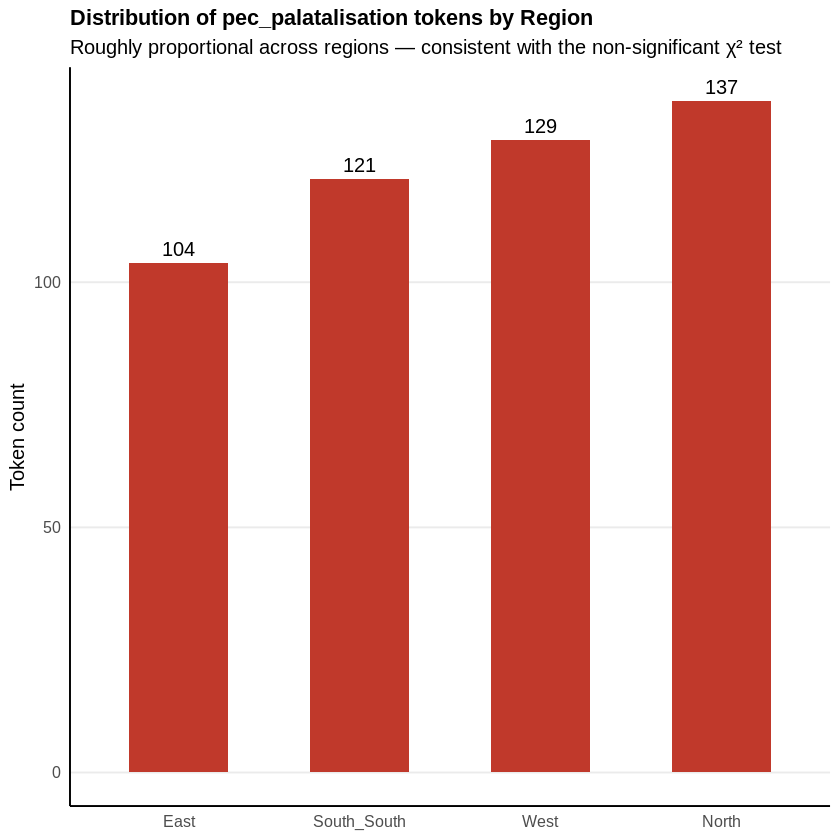

In [43]:
# pec_palatalisation makes up ~98% of the non-canonical tokens — worth a
# standalone view of where it occurs, since the earlier plots make it easy
# to miss against palatal-affricate/palatalised-voiced/pec_non-palatalised
df %>%
  filter(Realisation_clean == "pec_palatalisation") %>%
  count(Region) %>%
  mutate(Region = fct_reorder(Region, n)) %>%
  ggplot(aes(x = Region, y = n)) +
  geom_col(fill = "#C0392B", width = 0.55) +
  geom_text(aes(label = comma(n)), vjust = -0.5) +
  labs(
    title = "Distribution of pec_palatalisation tokens by Region",
    subtitle = "Roughly proportional across regions — consistent with the non-significant χ² test",
    x = NULL, y = "Token count"
  )

In [7]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] knitr_1.51          nnet_7.3-20         performance_0.17.1 
 [4] sjPlot_2.9.0        broom.mixed_0.2.9.7 car_3.1-5          
 [7] carData_3.0-6       lmerTest_3.2-1      lme4